# Final Project - Text Mining for AI

This notebook contains experiments and results for:
- sentiment analysis
- topic analysis
- named entity recognition/classification

# Imports

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import os
import pandas as pd

# ======================================
# SENTIMENT ANALYSIS
# ======================================

Dataset Loading and Preprocessing

In [3]:
data = []

dataset_path = "airlinetweets"

for label in ["positive", "negative", "neutral"]:
    folder_path = os.path.join(dataset_path, label)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()

            data.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(data)

In [4]:
df.head()

,text,label
0,"""@AmericanAir just curious. Thanks for the res...",positive
1,@united thanks for all the help! Totally appre...,positive
2,@JetBlue thanks. Line moved quick. Already done.,positive
3,@AmericanAir Aww cool! It's nice to know they ...,positive
4,@SouthwestAir Great job with the Passbook inte...,positive


In [5]:
print(df["label"].value_counts())

label
negative    1750
neutral     1515
positive    1490
Name: count, dtype: int64


SVM + TF-IDF Sentiment Analysis

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [12]:
# Create and train the model
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [9]:
# Predictions
predictions = model.predict(X_test)

In [ ]:
# Evaluation (classification report)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.84      0.90      0.87       328
     neutral       0.78      0.80      0.79       296
    positive       0.90      0.80      0.85       327

    accuracy                           0.84       951
   macro avg       0.84      0.84      0.84       951
weighted avg       0.84      0.84      0.84       951



The TF-IDF + SVM model achieved an accuracy of 84%. The model performs best on negative and positive sentiment, while neutral sentiment is slightly more difficult to classify.

In [11]:
for i in range(5):
    print("TEXT:", X_test.iloc[i])
    print("PREDICTED:", predictions[i])
    print("ACTUAL:", y_test.iloc[i])
    print("-" * 50)

TEXT: @SouthwestAir @SouthwestOliver that's a great FA right there.
PREDICTED: positive
ACTUAL: positive
--------------------------------------------------
TEXT: "@united flight landed 13 hours ago
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------
TEXT: "@united at its worse. Can't figure how to pack plane
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------
TEXT: @AmericanAir Am I upgraded on my next flight?
PREDICTED: neutral
ACTUAL: neutral
--------------------------------------------------
TEXT: @united that's cool - now what?
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------


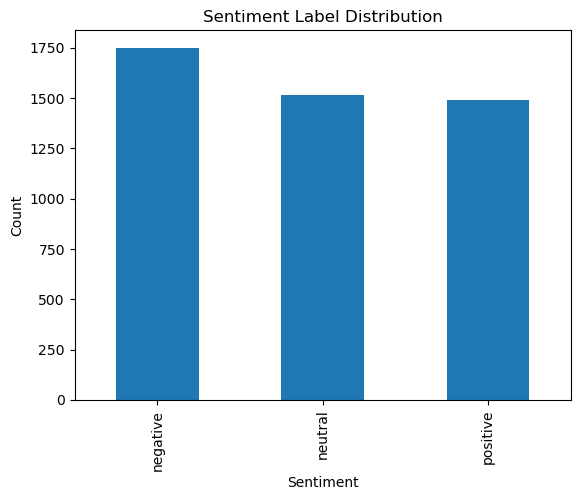

In [13]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()


ROBERTA Sentiment Analysis


Result Comparison and Error Analysis

In [ ]:
# code

# ======================================
# TOPIC ANALYSIS
# ======================================

Dataset Loading and Preprocessing

In [ ]:
# code

Topic Classification

In [ ]:
# code

Results

In [ ]:
# code

# ======================================
# NAMED ENTITY RECOGNITION (NER)
# ======================================

Dataset Loading and Preprocessing

In [ ]:
# code

NER System

In [ ]:
# code

Results

In [ ]:
# code

# End of notebook